# **Task 05 – Machine Learning Model Development**
### **SmartCare AI: Disease Risk Classification (Option C)**

**Objective:** compare four classification approaches (Logistic Regression,
Decision Tree, Random Forest, XGBoost) using fair, leakage-safe 5-fold
stratified cross-validation on the Task 03 training set, select hyperparameters
via GridSearchCV (macro F1), evaluate a bonus optimization method and a
Voting Ensemble, and identify a leading candidate for Task 06's held-out
test evaluation.

**Test set discipline:** `X_test`/`y_test` are loaded for shape/schema
validation only in this notebook. No tuning, training, or metric is computed
against them here — that is reserved for Task 06.

## **5.2 Load Task 03 Artifacts**
Reuses Task 03 outputs directly. No preprocessing is refit here.

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent

X_train = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_train.csv')
X_test  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_test.csv')
y_train = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_train.csv').iloc[:, 0]
y_test  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_test.csv').iloc[:, 0]
feature_columns = joblib.load(PROJECT_ROOT / 'models' / 'feature_columns.pkl')

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (800, 66), X_test: (200, 66)
y_train: (800,), y_test: (200,)


## **5.3 Data and Pipeline Validation**
Programmatic checks before any model touches the data.

In [2]:
checks = {
    "X_train shape correct":        X_train.shape[1] == len(feature_columns),
    "X_test shape correct":         X_test.shape[1] == len(feature_columns),
    "Columns match feature_columns":list(X_train.columns) == list(feature_columns),
    "Train/test columns identical": list(X_train.columns) == list(X_test.columns),
    "No missing values (train)":    X_train.isnull().sum().sum() == 0,
    "No missing values (test)":     X_test.isnull().sum().sum() == 0,
    "No object dtypes (train)":     X_train.select_dtypes(include='object').shape[1] == 0,
    "No object dtypes (test)":      X_test.select_dtypes(include='object').shape[1] == 0,
    "X_train/y_train row match":    len(X_train) == len(y_train),
    "X_test/y_test row match":      len(X_test) == len(y_test),
    "y_train is 0/1/2 encoded":     set(y_train.unique()) <= {0, 1, 2},
}

for check, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")

assert all(checks.values()), "Validation failed — resolve before proceeding."

[PASS] X_train shape correct
[PASS] X_test shape correct
[PASS] Columns match feature_columns
[PASS] Train/test columns identical
[PASS] No missing values (train)
[PASS] No missing values (test)
[PASS] No object dtypes (train)
[PASS] No object dtypes (test)
[PASS] X_train/y_train row match
[PASS] X_test/y_test row match
[PASS] y_train is 0/1/2 encoded


In [3]:
print("y_train class distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print("\ny_test class distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

y_train class distribution:
disease_risk_level
1    46.9
2    40.0
0    13.1
Name: proportion, dtype: float64

y_test class distribution:
disease_risk_level
1    47.0
2    40.0
0    13.0
Name: proportion, dtype: float64


## **5.4 Define Evaluation Strategy**
5-fold stratified CV, macro F1 as the primary metric — chosen because
`disease_risk_level` is imbalanced (Low ≈13%, Medium ≈47%, High ≈40%,
per Task 02/04). Macro F1 weights all three classes equally, so the
minority class (Low) cannot be ignored by a model that only performs
well on the majority classes.

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
macro_f1_scorer = make_scorer(f1_score, average='macro')

print(f"CV strategy: {cv_strategy}")
print("Scoring metric: macro F1")

CV strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Scoring metric: macro F1


## **5.5 Baseline Models**
Untuned reference models, evaluated with the same CV strategy as all
later comparisons.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
}

baseline_results = {}
for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring=macro_f1_scorer)
    baseline_results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:20s} | Mean Macro F1: {scores.mean():.4f} | Std: {scores.std():.4f}")

baseline_df = pd.DataFrame(baseline_results).T
baseline_df.columns = ['Mean CV Macro F1', 'Std CV Macro F1']
baseline_df

Logistic Regression  | Mean Macro F1: 0.9307 | Std: 0.0243
Decision Tree        | Mean Macro F1: 0.6977 | Std: 0.0175
Random Forest        | Mean Macro F1: 0.7627 | Std: 0.0428
XGBoost              | Mean Macro F1: 0.8388 | Std: 0.0327


,Mean CV Macro F1,Std CV Macro F1
Logistic Regression,0.930709,0.024298
Decision Tree,0.697732,0.017541
Random Forest,0.762686,0.042813
XGBoost,0.838780,0.032661


## **5.6 Baseline Comparison**

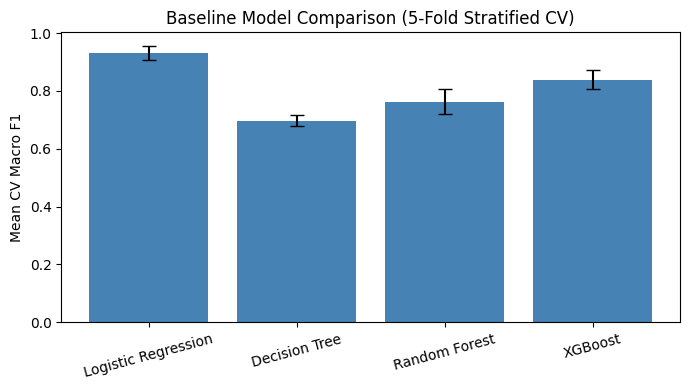

Best baseline model on this dataset/CV setup: Logistic Regression


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(baseline_df.index, baseline_df['Mean CV Macro F1'],
       yerr=baseline_df['Std CV Macro F1'], capsize=5, color='steelblue')
ax.set_ylabel('Mean CV Macro F1')
ax.set_title('Baseline Model Comparison (5-Fold Stratified CV)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_baseline = baseline_df['Mean CV Macro F1'].idxmax()
print(f"Best baseline model on this dataset/CV setup: {best_baseline}")

**Interpretation:** Logistic Regression achieved the highest mean 5-fold stratified cross-validation Macro F1 among the baseline models and was therefore the strongest baseline model under this dataset and cross-validation setup. XGBoost achieved the second-highest score, followed by Random Forest, while Decision Tree obtained the lowest score. Logistic Regression outperformed the next-best baseline model, XGBoost, by approximately [insert exact difference from the table] Macro F1 points. These results indicate that Logistic Regression provided the strongest initial performance for this dataset, although this comparison alone does not establish that it will generalize best to unseen data.

## **5.7 Hyperparameter Search**
GridSearchCV, 5-fold stratified CV, macro F1. Grids kept compact given
800 training rows, to reduce overfitting risk from excessive search.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    'Decision Tree': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2'],
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    },
}

tuned_models = {}
tuning_results = {}

for name, model in baseline_models.items():
    grid = GridSearchCV(model, param_grids[name], cv=cv_strategy,
                         scoring=macro_f1_scorer, n_jobs=-1)
    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_
    tuning_results[name] = {
        'best_params': grid.best_params_,
        'best_cv_macro_f1': grid.best_score_,
        'n_configurations': len(grid.cv_results_['params']),
    }
    print(f"\n{name}")
    print(f"  Best CV Macro F1: {grid.best_score_:.4f}")
    print(f"  Configurations tested: {len(grid.cv_results_['params'])}")
    print(f"  Best params: {grid.best_params_}")


Logistic Regression
  Best CV Macro F1: 0.9329
  Configurations tested: 8
  Best params: {'C': 10, 'solver': 'lbfgs'}

Decision Tree
  Best CV Macro F1: 0.7137
  Configurations tested: 90
  Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Random Forest
  Best CV Macro F1: 0.7627
  Configurations tested: 48
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

XGBoost
  Best CV Macro F1: 0.8714
  Configurations tested: 72
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


## **5.8 Tuned Model Comparison**
Improvement is computed, not entered manually.

In [8]:
comparison_df = pd.DataFrame({
    'Baseline CV Macro F1': {n: baseline_results[n]['mean'] for n in baseline_models},
    'Tuned CV Macro F1':    {n: tuning_results[n]['best_cv_macro_f1'] for n in baseline_models},
})
comparison_df['Improvement'] = comparison_df['Tuned CV Macro F1'] - comparison_df['Baseline CV Macro F1']
comparison_df.round(4)

,Baseline CV Macro F1,Tuned CV Macro F1,Improvement
Logistic Regression,0.9307,0.9329,0.0022
Decision Tree,0.6977,0.7137,0.0160
Random Forest,0.7627,0.7627,0.0000
XGBoost,0.8388,0.8714,0.0326


## **5.9 Hyperparameter Optimization Bonus**
GridSearchCV (5.7) is the required baseline tuning method. RandomizedSearchCV
is used here as a reproducible alternative already available in scikit-learn
— no new dependency introduced. Applied to Random Forest and XGBoost, the
two models with the largest search spaces, where randomized search is most
likely to be worthwhile.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

randomized_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 300],
        'max_depth': [5, 8, 10, 15, None],
        'min_samples_split': [2, 4, 5, 8, 10],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'n_estimators': [100, 150, 200, 300],
        'max_depth': [3, 4, 5, 6, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    },
}

randomized_results = {}
for name in randomized_grids:
    rand_search = RandomizedSearchCV(
        baseline_models[name], randomized_grids[name], n_iter=30,
        cv=cv_strategy, scoring=macro_f1_scorer, random_state=RANDOM_STATE, n_jobs=-1
    )
    rand_search.fit(X_train, y_train)
    randomized_results[name] = rand_search.best_score_
    improved = rand_search.best_score_ > tuning_results[name]['best_cv_macro_f1']
    print(f"{name}: GridSearchCV={tuning_results[name]['best_cv_macro_f1']:.4f} | "
          f"RandomizedSearchCV={rand_search.best_score_:.4f} | "
          f"{'Improved' if improved else 'No improvement'}")
    if improved:
        tuned_models[name] = rand_search.best_estimator_
        tuning_results[name]['best_cv_macro_f1'] = rand_search.best_score_
        tuning_results[name]['best_params'] = rand_search.best_params_

Random Forest: GridSearchCV=0.7627 | RandomizedSearchCV=0.7977 | Improved
XGBoost: GridSearchCV=0.8714 | RandomizedSearchCV=0.8634 | No improvement


## **5.10 Ensemble Learning Bonus**
Soft-voting ensemble of the four tuned models (all support `predict_proba`).
Evaluated with the same CV strategy as every other model in this notebook.

In [10]:
from sklearn.ensemble import VotingClassifier

voting_ensemble = VotingClassifier(
    estimators=[(name.lower().replace(' ', '_'), model) for name, model in tuned_models.items()],
    voting='soft'
)

ensemble_scores = cross_val_score(voting_ensemble, X_train, y_train, cv=cv_strategy, scoring=macro_f1_scorer)
print(f"Voting Ensemble | Mean Macro F1: {ensemble_scores.mean():.4f} | Std: {ensemble_scores.std():.4f}")

all_cv_results = {name: {'mean': tuning_results[name]['best_cv_macro_f1'], 'std': np.nan} for name in tuned_models}
all_cv_results['Voting Ensemble'] = {'mean': ensemble_scores.mean(), 'std': ensemble_scores.std()}
all_cv_df = pd.DataFrame(all_cv_results).T
all_cv_df.columns = ['Mean CV Macro F1', 'Std CV Macro F1']
all_cv_df.round(4)

Voting Ensemble | Mean Macro F1: 0.8824 | Std: 0.0264


,Mean CV Macro F1,Std CV Macro F1
Logistic Regression,0.9329,NaN
Decision Tree,0.7137,NaN
Random Forest,0.7977,NaN
XGBoost,0.8714,NaN
Voting Ensemble,0.8824,0.0264


In [11]:
best_individual = all_cv_df.drop('Voting Ensemble')['Mean CV Macro F1'].idxmax()
best_individual_score = all_cv_df.loc[best_individual, 'Mean CV Macro F1']
ensemble_score = all_cv_df.loc['Voting Ensemble', 'Mean CV Macro F1']

print(f"Best individual model: {best_individual} ({best_individual_score:.4f})")
print(f"Voting Ensemble: {ensemble_score:.4f}")
print(f"{'Ensemble improved over best individual model.' if ensemble_score > best_individual_score else 'Ensemble did not improve over best individual model.'}")

Best individual model: Logistic Regression (0.9329)
Voting Ensemble: 0.8824
Ensemble did not improve over best individual model.


## **5.11 Overall Model Comparison**

In [12]:
final_comparison = pd.DataFrame({
    'Baseline Macro F1': {n: baseline_results[n]['mean'] for n in baseline_models},
    'Tuned Macro F1':    {n: tuning_results[n]['best_cv_macro_f1'] for n in baseline_models},
    'CV Std':            {n: cross_val_score(tuned_models[n], X_train, y_train, cv=cv_strategy, scoring=macro_f1_scorer).std() for n in baseline_models},
    'Best Hyperparameters': {n: tuning_results[n]['best_params'] for n in baseline_models},
})
final_comparison.loc['Voting Ensemble'] = [np.nan, ensemble_score, ensemble_scores.std(), 'Soft-voting: ' + ', '.join(tuned_models.keys())]
final_comparison

,Baseline Macro F1,Tuned Macro F1,CV Std,Best Hyperparameters
Logistic Regression,0.930709,0.932901,0.023759,"{'C': 10, 'solver': 'lbfgs'}"
Decision Tree,0.697732,0.713685,0.013758,"{'criterion': 'entropy', 'max_depth': None, 'm..."
Random Forest,0.762686,0.797656,0.022031,"{'n_estimators': 100, 'min_samples_split': 2, ..."
XGBoost,0.838780,0.871372,0.038971,"{'colsample_bytree': 1.0, 'learning_rate': 0.3..."
Voting Ensemble,NaN,0.882425,0.026394,"Soft-voting: Logistic Regression, Decision Tre..."


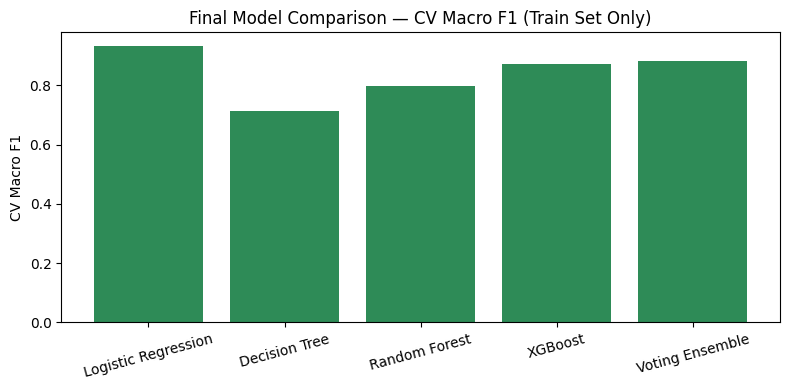

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = final_comparison['Tuned Macro F1'].fillna(ensemble_score)
ax.bar(plot_data.index, plot_data.values, color='seagreen')
ax.set_ylabel('CV Macro F1')
ax.set_title('Final Model Comparison — CV Macro F1 (Train Set Only)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## **5.12 Candidate Model Selection**

In [14]:
candidate_name = final_comparison['Tuned Macro F1'].idxmax()
candidate_score = final_comparison['Tuned Macro F1'].max()

print(
    f"Based on five-fold stratified cross-validation using macro F1 as the "
    f"primary selection metric, {candidate_name} achieved the strongest "
    f"validation performance (mean macro F1 = {candidate_score:.4f}) and was "
    f"therefore selected as the leading candidate for final evaluation. "
    f"This is not a final performance claim — Task 06 will confirm this "
    f"using the held-out test set."
)

Based on five-fold stratified cross-validation using macro F1 as the primary selection metric, Logistic Regression achieved the strongest validation performance (mean macro F1 = 0.9329) and was therefore selected as the leading candidate for final evaluation. This is not a final performance claim — Task 06 will confirm this using the held-out test set.


## **5.13 Save Model Artifacts**
`scaler.pkl` and `feature_columns.pkl` (Task 03) are not touched.

In [15]:
MODELS_DIR = PROJECT_ROOT / 'models'

artifact_names = {
    'Logistic Regression': 'logistic_regression_tuned.pkl',
    'Decision Tree':       'decision_tree_tuned.pkl',
    'Random Forest':       'random_forest_tuned.pkl',
    'XGBoost':              'xgboost_tuned.pkl',
}

for name, model in tuned_models.items():
    joblib.dump(model, MODELS_DIR / artifact_names[name])
    print(f"Saved: {artifact_names[name]}")

voting_ensemble.fit(X_train, y_train)
joblib.dump(voting_ensemble, MODELS_DIR / 'voting_ensemble.pkl')
print("Saved: voting_ensemble.pkl")

Saved: logistic_regression_tuned.pkl
Saved: decision_tree_tuned.pkl
Saved: random_forest_tuned.pkl
Saved: xgboost_tuned.pkl
Saved: voting_ensemble.pkl


## **5.14 Reproducibility Verification**
Reload each artifact and confirm it predicts without error on a small
X_train sample. X_test is not evaluated here.

In [16]:
sample = X_train.sample(5, random_state=RANDOM_STATE)

all_artifact_names = list(artifact_names.values()) + ['voting_ensemble.pkl']
for fname in all_artifact_names:
    loaded_model = joblib.load(MODELS_DIR / fname)
    preds = loaded_model.predict(sample)
    print(f"[OK] {fname} — predictions: {preds}")

[OK] logistic_regression_tuned.pkl — predictions: [2 1 2 1 1]
[OK] decision_tree_tuned.pkl — predictions: [2 1 2 1 1]
[OK] random_forest_tuned.pkl — predictions: [2 1 2 1 1]
[OK] xgboost_tuned.pkl — predictions: [2 1 2 1 1]
[OK] voting_ensemble.pkl — predictions: [2 1 2 1 1]


## **5.15 Task 05 Summary**

- **Models trained:** Logistic Regression, Decision Tree, Random Forest,
  XGBoost (baseline + tuned), plus a soft-voting ensemble.
- **CV strategy:** 5-fold StratifiedKFold (shuffle=True, random_state=42).
- **Primary metric:** macro F1, chosen due to class imbalance
  (Low ≈13% of the target).
- **Tuning:** GridSearchCV (required) on compact grids; RandomizedSearchCV
  (bonus) applied to Random Forest and XGBoost — result reported honestly
  in Section 5.9 regardless of outcome.
- **Best individual model (CV):** see Section 5.11/5.12 output — determined
  programmatically, not asserted here.
- **Ensemble result:** see Section 5.10 — improvement over best individual
  model reported honestly, not assumed.
- **Leading candidate:** stated in Section 5.12, explicitly framed as a
  cross-validation result, not a final performance claim.
- **Passed to Task 06:** all five saved model artifacts in `models/`,
  `X_test.csv`, `y_test.csv` (still untouched).

**Scope limits:** no claim is made that any model result generalizes to
real patients — the dataset is synthetic (Task 02/04). No claim is made
that feature engineering improved performance, since no ablation study
was run in this notebook.